# Employee Attrition Prediction + LIME Explanations (Example)

This notebook is the **end-to-end example application** that uses the API/wrapper layer from `lime_attrition_utils.py`.

It covers:
- **EDA** (attrition trends + correlations)
- **Feature engineering**
- **Model development** (gradient boosting models; compare metrics)
- **LIME explanations** (single employee + batch + aggregated drivers)
- **Reporting** (HR-friendly insights + recommendations)
- **Bonus**: feature-subset experiments and how explanations change


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

import lime_attrition_utils as u


## 1) Load + clean data (via wrapper API)

In [2]:
data_dir = Path("data")
csvs = sorted(data_dir.glob("*.csv"))
if not csvs:
    raise FileNotFoundError("No CSV found under ./data. Put the IBM HR Attrition dataset CSV in the data/ folder.")
csv_path = csvs[0]
print("Using dataset:", csv_path)

cfg = u.AttritionDataConfig()
df_raw = u.load_raw_attrition_data(str(csv_path))
df = u.clean_attrition_data(df_raw, cfg)

X, y = u.split_features_target(df, cfg)

print("Rows:", len(df), " | Features:", X.shape[1])
print("Attrition rate:", round(float(y.mean()), 4))
df.head()


Using dataset: data/WA_Fn-UseC_-HR-Employee-Attrition.csv
Rows: 1470  | Features: 30
Attrition rate: 0.1612


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


## 2) EDA — attrition trends and correlations

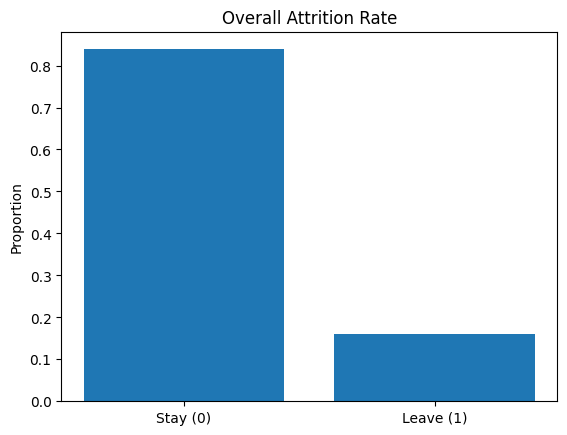

Overall attrition rate: 0.1612


In [3]:
# 2.1 Overall attrition rate
attr_rate = float(y.mean())
plt.figure()
plt.bar(["Stay (0)", "Leave (1)"], [1-attr_rate, attr_rate])
plt.title("Overall Attrition Rate")
plt.ylabel("Proportion")
plt.show()

print("Overall attrition rate:", round(attr_rate, 4))


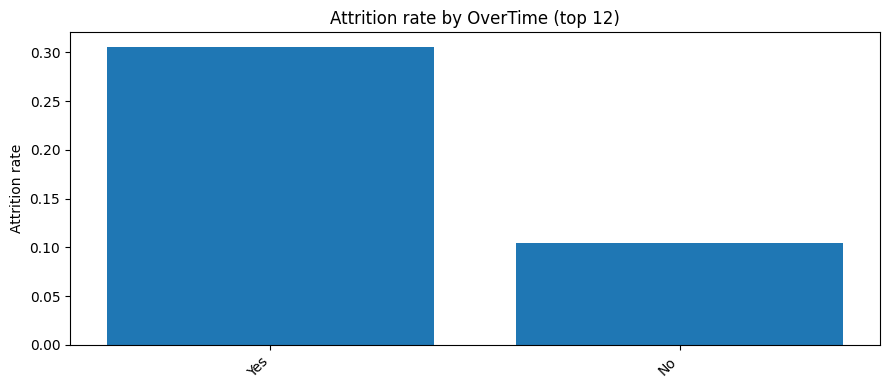

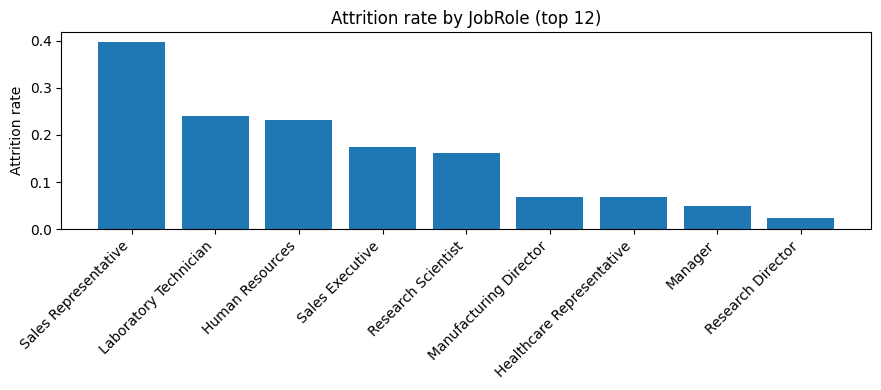

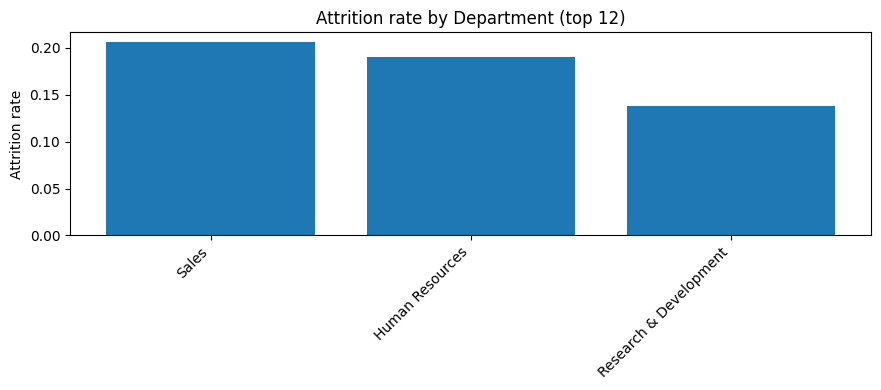

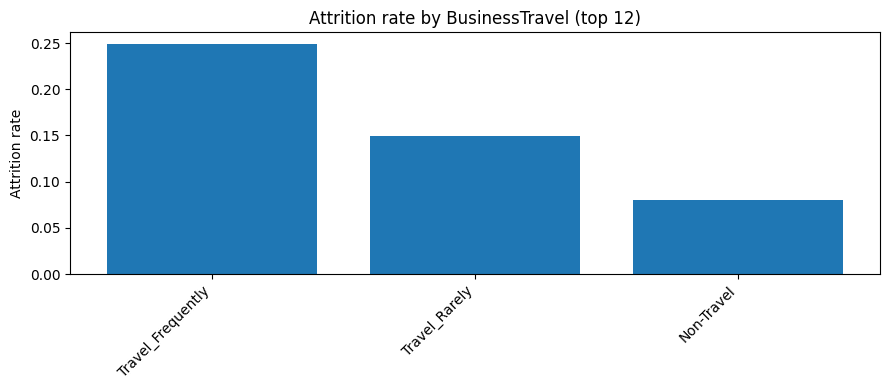

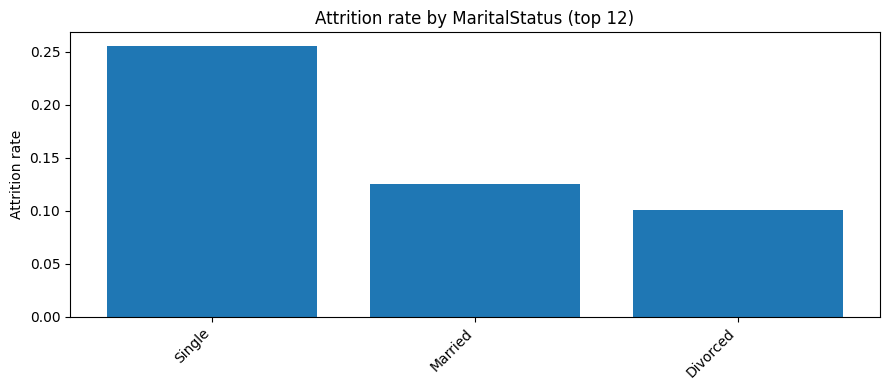

In [4]:
# 2.2 Attrition rate by key categorical features (if present)
def plot_attrition_rate_by_cat(df_full: pd.DataFrame, col: str, top_n: int = 10):
    if col not in df_full.columns:
        print(f"Skipping '{col}' (not found).")
        return
    tmp = df_full[[col, cfg.target_column]].copy()
    # Ensure target is numeric 0/1
    tmp[cfg.target_column] = pd.to_numeric(tmp[cfg.target_column], errors="coerce")
    rates = tmp.groupby(col)[cfg.target_column].mean().sort_values(ascending=False)
    rates = rates.head(top_n)
    plt.figure(figsize=(9, 4))
    plt.bar(rates.index.astype(str), rates.values)
    plt.title(f"Attrition rate by {col} (top {top_n})")
    plt.ylabel("Attrition rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Common IBM HR columns
for c in ["OverTime", "JobRole", "Department", "BusinessTravel", "MaritalStatus"]:
    plot_attrition_rate_by_cat(df, c, top_n=12)


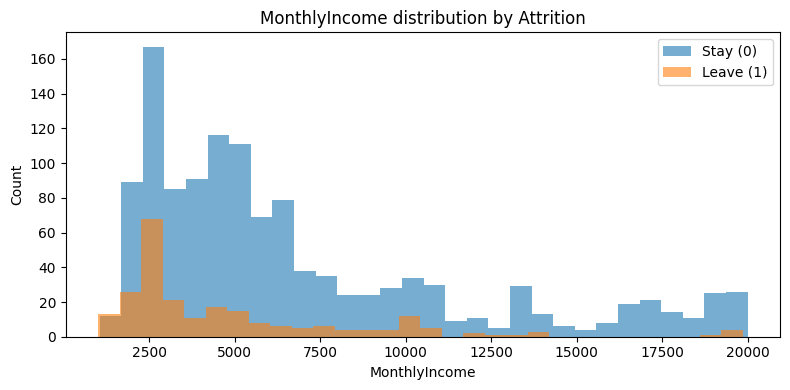

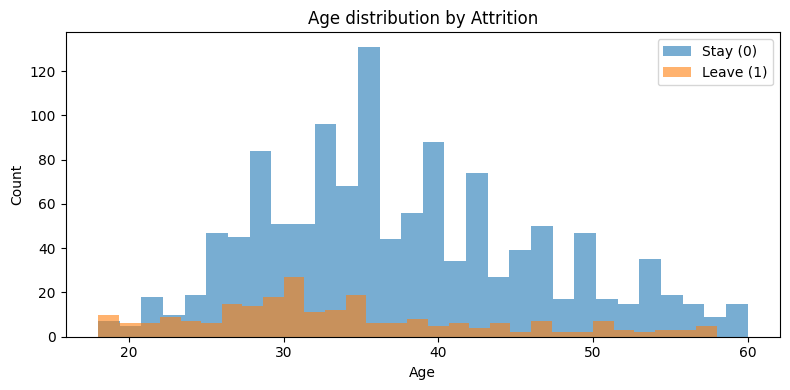

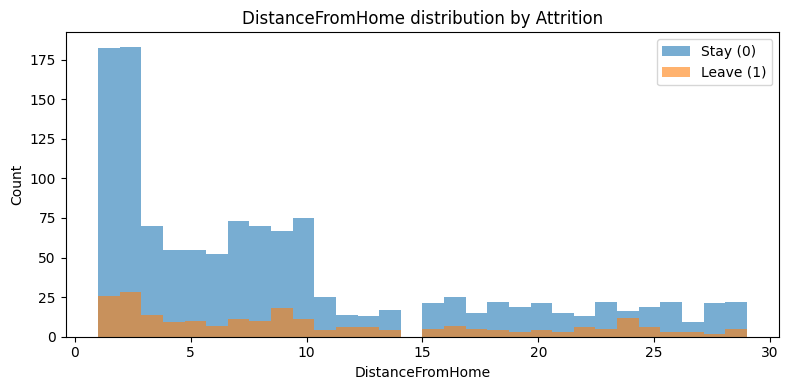

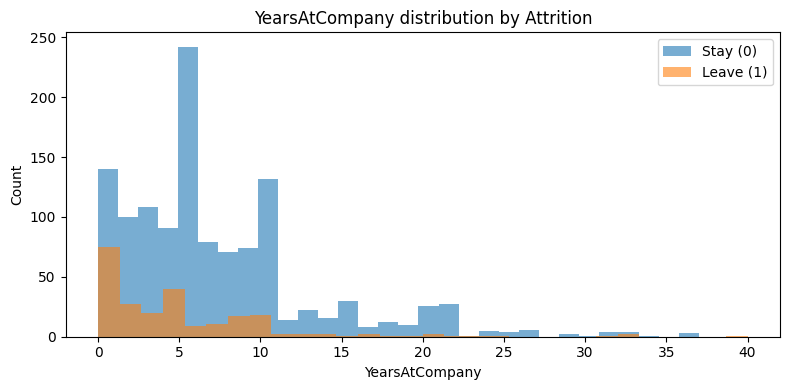

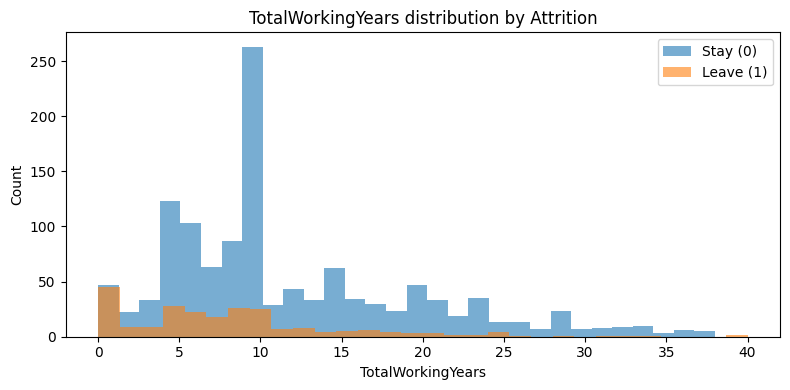

In [5]:
# 2.3 Numeric distributions by attrition (if present)
def plot_num_by_attrition(df_full: pd.DataFrame, col: str, bins: int = 30):
    if col not in df_full.columns:
        print(f"Skipping '{col}' (not found).")
        return
    stay = df_full[df_full[cfg.target_column] == 0][col].dropna()
    leave = df_full[df_full[cfg.target_column] == 1][col].dropna()
    plt.figure(figsize=(8, 4))
    plt.hist(stay, bins=bins, alpha=0.6, label="Stay (0)")
    plt.hist(leave, bins=bins, alpha=0.6, label="Leave (1)")
    plt.title(f"{col} distribution by Attrition")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

for c in ["MonthlyIncome", "Age", "DistanceFromHome", "YearsAtCompany", "TotalWorkingYears"]:
    plot_num_by_attrition(df, c)


In [6]:
# 2.4 Correlations (numeric features only) with attrition
num_cols = [c for c in df.columns if c != cfg.target_column and pd.api.types.is_numeric_dtype(df[c])]
if not num_cols:
    print("No numeric columns found for correlation table.")
else:
    corr = df[num_cols + [cfg.target_column]].corr(numeric_only=True)[cfg.target_column].sort_values(ascending=False)
    corr_df = corr.drop(cfg.target_column).to_frame("corr_with_attrition").reset_index().rename(columns={"index":"feature"})
    corr_df.head(15)


## 3) Feature engineering (create new features)

In [7]:
def add_engineered_features(X_in: pd.DataFrame) -> pd.DataFrame:
    X2 = X_in.copy()

    # Income per year at company (stabilize with +1)
    if {"MonthlyIncome", "YearsAtCompany"}.issubset(X2.columns):
        X2["IncomePerYearAtCompany"] = X2["MonthlyIncome"] / (X2["YearsAtCompany"] + 1)

    # Tenure ratio: years at company relative to total working years
    if {"YearsAtCompany", "TotalWorkingYears"}.issubset(X2.columns):
        X2["TenureRatio"] = X2["YearsAtCompany"] / (X2["TotalWorkingYears"] + 1)

    # Long commute flag
    if "DistanceFromHome" in X2.columns:
        X2["LongCommute"] = (X2["DistanceFromHome"] >= 10).astype(int)

    # Early career flag
    if "Age" in X2.columns:
        X2["EarlyCareer"] = (X2["Age"] <= 30).astype(int)

    return X2

X_fe = add_engineered_features(X)
print("Original features:", X.shape[1], " | After FE:", X_fe.shape[1])
set(X_fe.columns) - set(X.columns)


Original features: 30  | After FE: 34


{'EarlyCareer', 'IncomePerYearAtCompany', 'LongCommute', 'TenureRatio'}

## 4) Split + preprocess + model training (gradient boosting models)

In [8]:
# Split (wrapper uses stratification internally)
X_train, X_test, y_train, y_test = u.train_test_split_attrition(X_fe, y, cfg)

# Preprocessor + models
pre = u.build_preprocessor(X_train)

# Train multiple models for comparison
mcfg = u.ModelConfig(
    use_xgboost=True,
    use_lightgbm=True,
    use_random_forest=True,
)

models = u.train_attrition_models(X_train, y_train, pre, mcfg)
metrics = u.evaluate_models(models, X_test, y_test)

# Present metrics as a table
metrics_df = pd.DataFrame(metrics).T.sort_values(by=["pr_auc", "roc_auc"], ascending=False)
metrics_df


[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003735 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1544
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/home/dhanush/src/venv/client_venv.helpers/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/dhanush/src/venv/client_venv.helpers/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,accuracy,precision,recall,f1,roc_auc,pr_auc
xgboost,0.857143,0.692308,0.191489,0.300000,0.791024,0.514076
gradient_boosting,0.846939,0.562500,0.191489,0.285714,0.801275,0.472948
lightgbm,0.860544,0.714286,0.212766,0.327869,0.770954,0.456022
random_forest,0.846939,0.625000,0.106383,0.181818,0.793781,0.440558


In [9]:
# Choose best model (prefer PR AUC for imbalanced attrition)
metric_key = "pr_auc" if "pr_auc" in metrics_df.columns else "roc_auc"
best_model_name = metrics_df[metric_key].idxmax()
best_pipe = models[best_model_name]

print("Selected model:", best_model_name)
print("Best", metric_key, "=", float(metrics_df.loc[best_model_name, metric_key]))

# Save metrics artifact (optional)
Path("artifacts").mkdir(exist_ok=True)
metrics_df.to_csv("artifacts/model_metrics.csv", index=True)
print("Saved artifacts/model_metrics.csv")


Selected model: xgboost
Best pr_auc = 0.5140756620145737
Saved artifacts/model_metrics.csv


## 5) LIME explanations (single employee + batch + aggregated drivers)

In [10]:
# Identify a high-risk employee in the test set (highest predicted attrition probability)
probs = best_pipe.predict_proba(X_test)[:, 1]
top_idx = int(np.argmax(probs))
print("Top-risk test index:", top_idx, " | Predicted P(leave) =", float(probs[top_idx]))

row = X_test.iloc[top_idx]
row


Top-risk test index: 200  | Predicted P(leave) = 0.9861893057823181


Age                                           19
BusinessTravel                     Travel_Rarely
DailyRate                                    419
Department                                 Sales
DistanceFromHome                              21
Education                                      3
EducationField                             Other
EnvironmentSatisfaction                        4
Gender                                      Male
HourlyRate                                    37
JobInvolvement                                 2
JobLevel                                       1
JobRole                     Sales Representative
JobSatisfaction                                2
MaritalStatus                             Single
MonthlyIncome                               2121
MonthlyRate                                 9947
NumCompaniesWorked                             1
OverTime                                     Yes
PercentSalaryHike                             13
PerformanceRating   

In [11]:
# Build LIME explainer in the pipeline feature space
pre_fitted = best_pipe.named_steps["preprocess"]
explainer = u.build_lime_explainer(pre_fitted, X_train, class_names=["Stay", "Leave"])

# Explain the top-risk employee using wrapper
lcfg = u.LimeConfig(num_features=10, num_samples=5000)
exp = u.explain_single_employee(explainer, best_pipe, row, pre_fitted, lcfg)

# Inspect explanation
exp_list = exp.as_list()
exp_list


[('cat__OverTime_No <= 0.00', 0.134222373739934),
 ('num__JobInvolvement <= -1.05', 0.11664317365464612),
 ('num__StockOptionLevel <= -0.94', 0.10628347860903552),
 ('num__MonthlyIncome <= -0.77', 0.09031225881123377),
 ('num__DistanceFromHome > 0.57', 0.08142126364595766),
 ('num__NumCompaniesWorked <= -0.68', -0.07523170979073109),
 ('num__Age <= -0.76', 0.07327664599412255),
 ('cat__BusinessTravel_Travel_Frequently <= 0.00', -0.07050550146804414),
 ('num__RelationshipSatisfaction <= -0.68', 0.06718114029188227),
 ('0.26 < num__EnvironmentSatisfaction <= 1.18', -0.0623500922377951)]

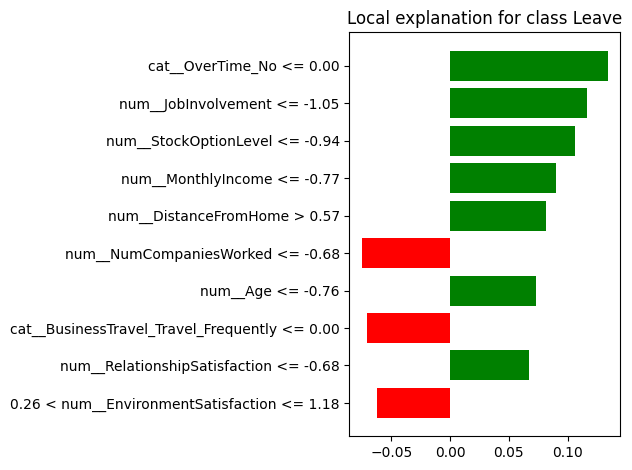

Saved artifacts/lime_explanation_toprisk.html


In [12]:
# Plot the explanation (native LIME output)
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

# Optional: save HTML artifact
Path("artifacts").mkdir(exist_ok=True)
exp.save_to_file("artifacts/lime_explanation_toprisk.html")
print("Saved artifacts/lime_explanation_toprisk.html")


In [13]:
# Batch: top-N risky employees + their top local drivers (HR-facing table)
top_tbl = u.batch_lime_explanations(
    explainer=explainer,
    model_pipeline=best_pipe,
    X=X_test,
    y=y_test,
    preprocessor=pre_fitted,
    lime_config=lcfg,
    top_n=10,
    top_k_features=5,
)

top_tbl.to_csv("artifacts/top_risk_employees_lime.csv", index=False)
print("Saved artifacts/top_risk_employees_lime.csv")
top_tbl


Saved artifacts/top_risk_employees_lime.csv


,rank,row_index,predicted_leave_prob,top_factors,actual_attrition
0,1,688,0.986189,cat__OverTime_No <= 0.00 (+0.14); num__JobInvo...,1
1,2,911,0.981625,cat__OverTime_No <= 0.00 (+0.13); num__JobInvo...,1
2,3,357,0.911347,cat__OverTime_No <= 0.00 (+0.13); num__JobInvo...,1
3,4,301,0.875164,0.00 < cat__OverTime_No <= 1.00 (-0.13); num__...,0
4,5,711,0.861368,cat__OverTime_No <= 0.00 (+0.13); num__NumComp...,1
5,6,762,0.816559,cat__OverTime_No <= 0.00 (+0.13); num__NumComp...,1
6,7,514,0.781209,cat__OverTime_No <= 0.00 (+0.14); num__StockOp...,1
7,8,1402,0.725877,cat__OverTime_No <= 0.00 (+0.13); num__JobInvo...,0
8,9,946,0.691885,cat__OverTime_No <= 0.00 (+0.14); num__JobInvo...,1
9,10,2,0.684618,num__NumCompaniesWorked > 0.53 (+0.12); cat__O...,1


In [14]:
# Aggregated drivers: run LIME on top-N and aggregate to get common drivers pushing toward attrition
long_df = u.batch_lime_explanations_long(
    explainer=explainer,
    model_pipeline=best_pipe,
    X=X_test,
    y=y_test,
    preprocessor=pre_fitted,
    lime_config=lcfg,
    top_n=50,
    top_k_features=10,
)

agg_df = u.aggregate_lime_features(long_df)
agg_df.to_csv("artifacts/lime_aggregate_drivers.csv", index=False)
print("Saved artifacts/lime_aggregate_drivers.csv")

agg_df.head(15)


Saved artifacts/lime_aggregate_drivers.csv


,feature_hr,count,mean_weight,mean_abs_weight,pct_push_leave
0,OverTime ≠ No,30,0.131059,0.131059,1.0
1,0.00 < cat__OverTime_No <= 1.00,20,-0.130438,0.130438,0.0
2,NumCompaniesWorked is high,14,0.118864,0.118864,1.0
3,JobInvolvement is low,26,0.116193,0.116193,1.0
4,EnvironmentSatisfaction is low,26,0.099989,0.099989,1.0
5,StockOptionLevel is low,37,0.094585,0.094585,1.0
6,MonthlyIncome is low,26,0.086930,0.086930,1.0
7,-1.05 < num__JobInvolvement <= 0.37,20,-0.083325,0.083325,0.0
8,WorkLifeBalance is low,13,0.081580,0.081580,1.0
9,DistanceFromHome is high,12,0.076030,0.076030,1.0


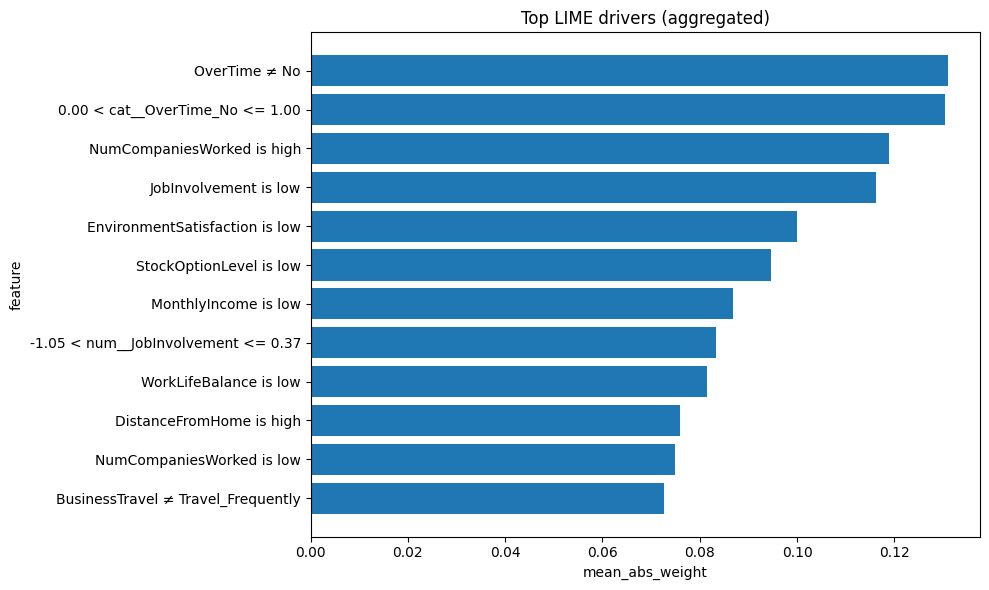

In [15]:
# Compatibility: plot helper expects column name "feature"
if "feature" not in agg_df.columns and "feature_hr" in agg_df.columns:
    agg_df_plot = agg_df.rename(columns={"feature_hr": "feature"})
else:
    agg_df_plot = agg_df.copy()

u.plot_lime_aggregate_bar(agg_df_plot, top_n=12)
plt.tight_layout()
plt.show()


## 6) Bonus — feature subset experiments (how explanations change)

In [16]:
# Helper: extract a stable "feature key" from a LIME feature string
def lime_feature_key(s: str) -> str:
    # Handles patterns like:
    #   "cat__JobRole_Sales Executive <= 0.00"
    #   "0.00 < cat__OverTime_No <= 1.00"
    #   "num__MonthlyIncome <= -0.77"
    s2 = s.strip()
    if " < " in s2:
        # drop leading bound "0.00 < "
        s2 = s2.split(" < ", 1)[1].strip()
    # cut at comparison operators
    for op in [" <= ", " >= ", " < ", " > "]:
        if op in s2:
            s2 = s2.split(op, 1)[0].strip()
    return s2

def top_k_keys(exp_obj, k: int = 10):
    pairs = exp_obj.as_list()
    keys = [lime_feature_key(name) for name, _w in pairs[:k]]
    # de-dup while preserving order
    seen = set()
    out = []
    for x in keys:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

# Full-model reference explanation keys
ref_keys = top_k_keys(exp, k=10)
ref_keys


['cat__OverTime_No',
 'num__JobInvolvement',
 'num__StockOptionLevel',
 'num__MonthlyIncome',
 'num__DistanceFromHome',
 'num__NumCompaniesWorked',
 'num__Age',
 'cat__BusinessTravel_Travel_Frequently',
 'num__RelationshipSatisfaction',
 'num__EnvironmentSatisfaction']

In [17]:
# Define feature subsets (choose columns that exist)
all_cols = list(X_fe.columns)

subset_defs = {
    "All+FE (reference)": all_cols,
    "No OverTime": [c for c in all_cols if not c.startswith("OverTime") and c != "OverTime"],
    "No Income": [c for c in all_cols if c != "MonthlyIncome" and c != "IncomePerYearAtCompany"],
    "Core HR subset": [c for c in all_cols if c in {
        "Age","MonthlyIncome","OverTime","JobRole","DistanceFromHome","YearsAtCompany",
        "WorkLifeBalance","JobSatisfaction","BusinessTravel","MaritalStatus","Department",
        "IncomePerYearAtCompany","TenureRatio","LongCommute","EarlyCareer"
    }],
}

# Filter out any empty/invalid subsets
subset_defs = {k:[c for c in v if c in all_cols] for k,v in subset_defs.items() if len(v) > 5}
subset_defs.keys()


dict_keys(['All+FE (reference)', 'No OverTime', 'No Income', 'Core HR subset'])

In [18]:
def train_best_like_model(Xtr, ytr, Xte, yte, subset_cols):
    # Train the same *type* of model as best_model_name where possible.
    # Fallback: whatever is available from train_attrition_models().
    Xtr_s = Xtr[subset_cols].copy()
    Xte_s = Xte[subset_cols].copy()
    pre_s = u.build_preprocessor(Xtr_s)

    # Configure to prefer the selected model type
    mcfg_s = u.ModelConfig(
        use_xgboost=("xgboost" in best_model_name.lower()),
        use_lightgbm=("lightgbm" in best_model_name.lower()),
        use_random_forest=("random_forest" in best_model_name.lower()),
    )
    models_s = u.train_attrition_models(Xtr_s, ytr, pre_s, mcfg_s)
    metrics_s = u.evaluate_models(models_s, Xte_s, yte)
    mdf_s = pd.DataFrame(metrics_s).T
    key = "pr_auc" if "pr_auc" in mdf_s.columns else "roc_auc"
    best_name_s = mdf_s[key].idxmax()
    return best_name_s, models_s[best_name_s], mdf_s.loc[best_name_s].to_dict()

results = []
for subset_name, cols in subset_defs.items():
    # Skip the reference (we already ran it)
    if subset_name == "All+FE (reference)":
        continue

    best_name_s, pipe_s, met_s = train_best_like_model(X_train, y_train, X_test, y_test, cols)

    # explain same employee row, but reduced to subset columns
    row_s = row[cols]
    pre_s = pipe_s.named_steps["preprocess"]
    expl_s = u.build_lime_explainer(pre_s, X_train[cols], ["Stay","Leave"])
    exp_s = u.explain_single_employee(expl_s, pipe_s, row_s, pre_s, lcfg)

    keys_s = top_k_keys(exp_s, k=10)
    jacc = len(set(keys_s) & set(ref_keys)) / max(1, len(set(keys_s) | set(ref_keys)))

    prob_s = float(pipe_s.predict_proba(X_test[cols])[:,1][top_idx])

    results.append({
        "subset": subset_name,
        "trained_model": best_name_s,
        "pred_prob_leave_same_employee": prob_s,
        "jaccard_top10_vs_reference": jacc,
        "roc_auc": met_s.get("roc_auc", np.nan),
        "pr_auc": met_s.get("pr_auc", np.nan),
    })

subset_results = pd.DataFrame(results).sort_values(by="jaccard_top10_vs_reference", ascending=True)
subset_results.to_csv("artifacts/feature_subset_results.csv", index=False)
print("Saved artifacts/feature_subset_results.csv")
subset_results


Saved artifacts/feature_subset_results.csv


,subset,trained_model,pred_prob_leave_same_employee,jaccard_top10_vs_reference,roc_auc,pr_auc
2,Core HR subset,xgboost,0.981240,0.333333,0.760014,0.429327
1,No Income,xgboost,0.966402,0.538462,0.800844,0.543953
0,No OverTime,xgboost,0.899724,0.666667,0.717891,0.366515


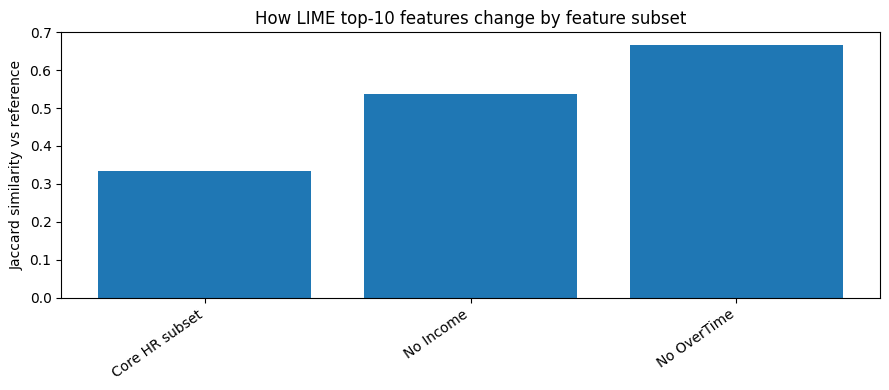

In [19]:
# Visualize how much the explanation changes (lower Jaccard = more change)
plt.figure(figsize=(9,4))
plt.bar(subset_results["subset"], subset_results["jaccard_top10_vs_reference"])
plt.title("How LIME top-10 features change by feature subset")
plt.ylabel("Jaccard similarity vs reference")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 7) Reporting — HR-friendly insights and recommendations

In [20]:
# Quick auto-summary helpers (use these outputs in lime_attrition.example.md)
print("=== Model selected ===")
print(best_model_name)
print("\n=== Top aggregated drivers (first 10 rows) ===")
display(agg_df.head(10))

print("\n=== Suggested HR narrative prompts ===")
print("- Which groups show higher attrition in EDA? (OverTime, JobRole, BusinessTravel, etc.)")
print("- What features most commonly push toward 'Leave' in aggregated LIME?")
print("- Do explanations change meaningfully when removing OverTime / Income features (bonus)?")


=== Model selected ===
xgboost

=== Top aggregated drivers (first 10 rows) ===


,feature_hr,count,mean_weight,mean_abs_weight,pct_push_leave
0,OverTime ≠ No,30,0.131059,0.131059,1.0
1,0.00 < cat__OverTime_No <= 1.00,20,-0.130438,0.130438,0.0
2,NumCompaniesWorked is high,14,0.118864,0.118864,1.0
3,JobInvolvement is low,26,0.116193,0.116193,1.0
4,EnvironmentSatisfaction is low,26,0.099989,0.099989,1.0
5,StockOptionLevel is low,37,0.094585,0.094585,1.0
6,MonthlyIncome is low,26,0.086930,0.086930,1.0
7,-1.05 < num__JobInvolvement <= 0.37,20,-0.083325,0.083325,0.0
8,WorkLifeBalance is low,13,0.081580,0.081580,1.0
9,DistanceFromHome is high,12,0.076030,0.076030,1.0



=== Suggested HR narrative prompts ===
- Which groups show higher attrition in EDA? (OverTime, JobRole, BusinessTravel, etc.)
- What features most commonly push toward 'Leave' in aggregated LIME?
- Do explanations change meaningfully when removing OverTime / Income features (bonus)?
